In [5]:
import json
from sentence_transformers import SentenceTransformer, util
from google.colab import drive
drive.mount('/content/drive')

import json

# Chemin vers ton fichier dans Drive
file_path = '/content/drive/MyDrive/data.json'

with open(file_path, 'r', encoding='utf-8') as f:
    theses_data = json.load(f)

# 2. DÉDOUBLONNAGE DES TITRES
# On utilise un dictionnaire pour s'assurer que chaque titre n'apparaît qu'une seule fois
theses_uniques = {}
for these in theses_data:
    titre = these.get('titre', '').strip()
    # Si le titre n'est pas vide et n'a pas encore été vu, on l'ajoute
    if titre and titre not in theses_uniques:
        theses_uniques[titre] = these

# On recrée nos listes propres
titres = list(theses_uniques.keys())
ids = [theses_uniques[t].get('id', 'ID_INCONNU') for t in titres]

print(f"Total des thèses dans le fichier : {len(theses_data)}")
print(f"Total des thèses après suppression des titres identiques : {len(titres)}")

# 3. Chargement du modèle
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 4. Génération des vecteurs
print("Génération des vecteurs en cours...")
embeddings = model.encode(titres, convert_to_tensor=True, show_progress_bar=True)

# 5. Calcul des similarités
print("Calcul des similarités...")
paires_similaires = util.paraphrase_mining(model, titres)

# 6. AFFICHAGE FILTRÉ
print("\n--- TOP 10 DES THÈSES SIMILAIRES (MAIS DIFFÉRENTES) ---")
resultats_affiches = 0

for score, i, j in paires_similaires:
    # On arrête la boucle une fois qu'on a affiché nos 10 résultats
    if resultats_affiches >= 20:
        break
        
    # FILTRE DE SÉCURITÉ :
    # On ignore les scores de 1.0 ou > 0.98 (qui sont des copies)
    # On vérifie aussi (par précaution) que les titres mis en minuscules ne sont pas identiques
    titre1 = titres[i].lower()
    titre2 = titres[j].lower()
    
    if titre1 != titre2 and score < 0.98:
        print(f"\nScore de similarité : {score:.4f}")
        print(f"Thèse 1 ({ids[i]}) : {titres[i]}")
        print(f"Thèse 2 ({ids[j]}) : {titres[j]}")
        
        resultats_affiches += 1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total des thèses dans le fichier : 9229
Total des thèses après suppression des titres identiques : 9229


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Génération des vecteurs en cours...


Batches:   0%|          | 0/289 [00:00<?, ?it/s]

Calcul des similarités...

--- TOP 10 DES THÈSES SIMILAIRES (MAIS DIFFÉRENTES) ---

Score de similarité : 0.9787
Thèse 1 (2022SORUS364) : Photonic Resources for the Implementation of Quantum Network Protocols
Thèse 2 (2025SORUS076) : Implementation of Protocols for Quantum Photonic Networks

Score de similarité : 0.9740
Thèse 1 (2022PA01E051) : Essays on Empirical Corporate Finance
Thèse 2 (2022ESEC0003) : Essays on corporate finance

Score de similarité : 0.9734
Thèse 1 (s404552) : Repartir à zéro et reconstruire une vie. Résilience chez des anciens combattants. Le cas dun groupe de démobilisés des forces armées révolutionnaires de Colombie (FARC).
Thèse 2 (2024LYO20008) : Repartir à zéro et reconstruire une vie. Résilience chez des anciens combattants : Le cas d’un groupe de démobilisés des forces armées révolutionnaires de Colombie (FARC)

Score de similarité : 0.9723
Thèse 1 (2021GRALY050) : Cosmologie à partir des observations Sunyaev-Zeldovich d’amas de galaxies avec NIKA2
Thèse

In [6]:
from collections import defaultdict

with open(file_path, 'r', encoding='utf-8') as f:
    theses_data = json.load(f)

# 2. Regroupement par titre
# defaultdict permet de créer facilement un dictionnaire où chaque clé 
# contient une liste de thèses ayant le même titre.
theses_groupees = defaultdict(list)

for these in theses_data:
    titre_original = these.get('titre', '')
    if titre_original:
        # On utilise le titre en minuscules pour s'assurer qu'une simple 
        # différence de majuscule ne cache pas un doublon
        titre_cle = titre_original.strip().lower()
        theses_groupees[titre_cle].append(these)

# 3. Filtrage pour ne garder QUE les doublons (titres apparus > 1 fois)
doublons = {titre: liste_theses for titre, liste_theses in theses_groupees.items() if len(liste_theses) > 1}

# Calcul du nombre total de thèses supprimées (copies supplémentaires)
total_theses_supprimees = sum(len(liste) - 1 for liste in doublons.values())

# 4. Affichage des résultats
print("=" * 70)
print(f"Total des thèses dans le fichier brut : {len(theses_data)}")
print(f"Nombre de titres uniques ayant des doublons : {len(doublons)}")
print(f"Nombre exact de copies qui seront supprimées lors du nettoyage : {total_theses_supprimees}")
print("=" * 70)

for titre_cle, liste_theses in doublons.items():
    # On récupère le vrai titre avec ses majuscules depuis la première thèse de la liste
    vrai_titre = liste_theses[0].get('titre', '').strip()
    
    print(f"\n▶ TITRE IDENTIQUE TROUVÉ ({len(liste_theses)} fois) :")
    print(f"  {vrai_titre}")
    
    # On affiche les détails de chaque copie l'une après l'autre
    for i, these in enumerate(liste_theses):
        id_these = these.get('id', 'ID_INCONNU')
        annee = these.get('annee', 'Année inconnue')
        etablissement = these.get('etablissement', 'Établissement inconnu')
        
        print(f"    - Copie {i + 1} | ID: {id_these} | Année: {annee} | Établissement: {etablissement}")

Total des thèses dans le fichier brut : 9229
Nombre de titres uniques ayant des doublons : 0
Nombre exact de copies qui seront supprimées lors du nettoyage : 0


In [7]:
import json
import nltk
from nltk.stem.snowball import SnowballStemmer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Initialisation du "découpeur de racines" en français
# Il permettra d'identifier que "politique" et "politiques" sont le même mot
stemmer = SnowballStemmer("french")

# 1. Chargement et nettoyage des données
with open(file_path, 'r', encoding='utf-8') as f:
    theses_data = json.load(f)

titres_uniques = []
for these in theses_data:
    titre = these.get('titre', '').strip()
    if titre and titre not in titres_uniques:
        titres_uniques.append(titre)

print(f"Nombre de thèses à analyser : {len(titres_uniques)}")

# 2. Vectorisation SBERT et Clustering K-Means
print("Génération des vecteurs SBERT...")
model_sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model_sbert.encode(titres_uniques)

NOMBRE_DE_CLUSTERS = 5
print(f"Création de {NOMBRE_DE_CLUSTERS} thématiques...")
kmeans = KMeans(n_clusters=NOMBRE_DE_CLUSTERS, random_state=42)
labels_clusters = kmeans.fit_predict(embeddings)

# 3. Organisation des titres par cluster
clusters_titres = {i: [] for i in range(NOMBRE_DE_CLUSTERS)}
for titre, label in zip(titres_uniques, labels_clusters):
    clusters_titres[label].append(titre)

# 4. PRÉPARATION DU TF-IDF MULTILINGUE
mots_vides_fr = [
    "le", "la", "les", "de", "des", "un", "une", "et", "en", "dans", "sur", 
    "pour", "par", "avec", "qui", "que", "du", "au", "aux", "ou", "est", 
    "sont", "à", "pas", "plus", "vers", "leur", "leurs", "ce", "ces", "se", 
    "sa", "son", "ses", "l", "d", "qu", "entre", "sous", "cas", "étude", 
    "analyse", "thèse", "contribution", "approche", "dynamique", "impact",
    "essai", "recherche", "vers", "comment"
]
mots_vides_multilingues = mots_vides_fr + list(ENGLISH_STOP_WORDS)

documents_clusters = [" ".join(clusters_titres[i]) for i in range(NOMBRE_DE_CLUSTERS)]

vectorizer = TfidfVectorizer(stop_words=mots_vides_multilingues, max_features=2000)
tfidf_matrix = vectorizer.fit_transform(documents_clusters)
mots_du_vocabulaire = vectorizer.get_feature_names_out()

# 5. EXTRACTION INTELLIGENTE ET AFFICHAGE DES RÉSULTATS
print("\n" + "="*60)
print(" RÉSULTATS DU CLUSTERING (AVEC FILTRE ANTI-DOUBLONS)")
print("="*60)

for i in range(NOMBRE_DE_CLUSTERS):
    scores_du_cluster = tfidf_matrix[i].toarray().flatten()
    
    # On récupère TOUS les mots triés par score d'importance
    indices_tries = scores_du_cluster.argsort()[::-1]
    
    mots_cles_finaux = []
    racines_vues = set() # Pour mémoriser les racines déjà utilisées
    
    # On parcourt les mots du plus important au moins important
    for idx in indices_tries:
        mot = mots_du_vocabulaire[idx]
        
        # On extrait la racine du mot (ex: "politiques" -> "politiqu")
        racine = stemmer.stem(mot)
        
        # Si on n'a pas encore vu cette racine et que le mot fait plus de 2 lettres
        if racine not in racines_vues and len(mot) > 2:
            racines_vues.add(racine)
            mots_cles_finaux.append(mot)
            
        # On s'arrête dès qu'on a trouvé 5 concepts uniques
        if len(mots_cles_finaux) >= 5:
            break
            
    # Hiérarchisation : Le mot #1 devient la Thématique Générale, les autres sont les mots-clés
    thematique_generale = mots_cles_finaux[0].upper()
    mots_cles_secondaires = [mot.capitalize() for mot in mots_cles_finaux[1:]]
    
    print(f"\n▶ GROUPE {i + 1} ({len(clusters_titres[i])} thèses)")
    print(f"  Thématique générale : {thematique_generale}")
    print(f"  Mots-clés associés  : {', '.join(mots_cles_secondaires)}")
    print("-" * 50)
    
    # Affichage de 3 exemples de titres
    for titre in clusters_titres[i][:3]:
        print(f"  • {titre}")

Nombre de thèses à analyser : 9229
Génération des vecteurs SBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Création de 5 thématiques...

 RÉSULTATS DU CLUSTERING (AVEC FILTRE ANTI-DOUBLONS)

▶ GROUPE 1 (1829 thèses)
  Thématique générale : POLITIQUE
  Mots-clés associés  : France, Femmes, Afrique, Sociale
--------------------------------------------------
  • Et pourtant... elles bossent ! : Trajectoires migratoires et professionnelles de femmes immigrées du Maghreb en France dans la seconde moitié du XXe siècle
  • Les habitants invisibles des friches de la ville : abris discrets et incertains dans les terrains vagues et les délaissés autoroutiers aux abords de Paris
  • Les cercles « halal » : discuter l’islam dans un contexte européen. Le cas des sohbet des jeunes étudiantes musulmanes en France et en Allemagne

▶ GROUPE 2 (1602 thèses)
  Thématique générale : ENTREPRISES
  Mots-clés associés  : Innovation, Management, Gestion, Essays
--------------------------------------------------
  • Contributions à la gestion de crise « cyber » : une approche juridique et managériale
  • La partici


Génération du graphique en cours (Réduction t-SNE)...
✅ Le graphique a été généré et sauvegardé avec succès sous le nom : clustering_theses_sbert.png


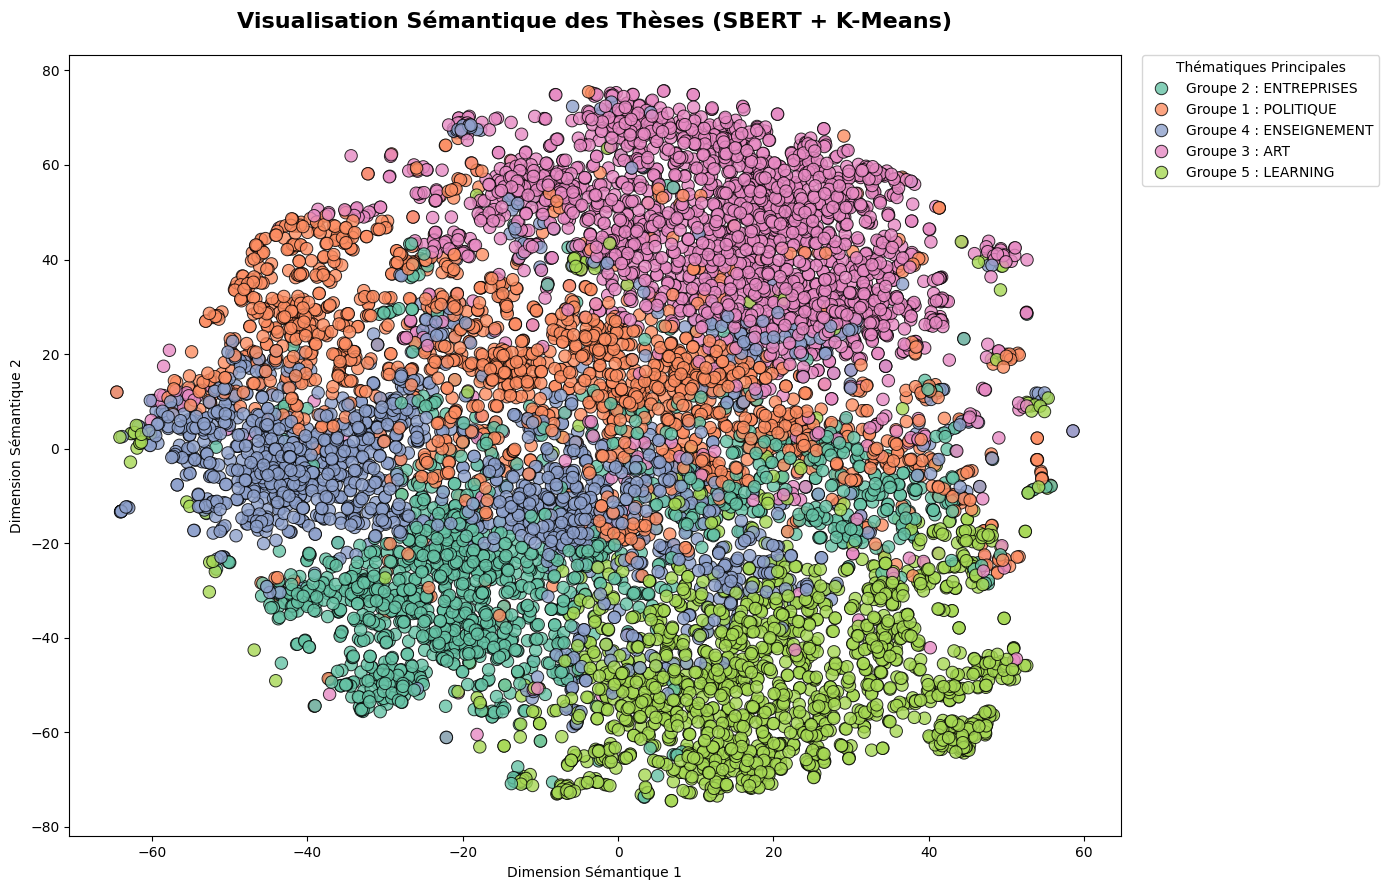

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# (Assurez-vous d'ajouter ce code APRÈS avoir généré 'embeddings' et 'labels_clusters')

print("\nGénération du graphique en cours (Réduction t-SNE)...")

# 1. RÉDUCTION DE DIMENSION (384D -> 2D)
# L'algorithme t-SNE est excellent pour séparer visuellement des clusters complexes
# La perplexité est ajustée automatiquement pour ne pas faire d'erreur sur des petits corpus
perplexite = min(30, max(1, len(titres_uniques) // 2))
tsne_model = TSNE(n_components=2, random_state=42, perplexity=perplexite)

# On transforme nos vecteurs SBERT en coordonnées X/Y
coordonnees_2d = tsne_model.fit_transform(embeddings)

# 2. PRÉPARATION DES DONNÉES POUR LE GRAPHIQUE
# On récupère le mot numéro 1 (Thématique principale) de chaque groupe 
# calculé par le TF-IDF précédemment pour faire une jolie légende
noms_groupes = []
for label in labels_clusters:
    # On récupère les scores TF-IDF du groupe
    scores = tfidf_matrix[label].toarray().flatten()
    mot_principal_idx = scores.argsort()[-1] # Le mot le plus fort
    mot_principal = mots_du_vocabulaire[mot_principal_idx].upper()
    noms_groupes.append(f"Groupe {label+1} : {mot_principal}")

# Création d'un tableau de données (DataFrame) compréhensible par la librairie graphique
df_graphique = pd.DataFrame({
    'X': coordonnees_2d[:, 0],
    'Y': coordonnees_2d[:, 1],
    'Thématique': noms_groupes,
    'Titre': titres_uniques
})

# 3. CRÉATION DU GRAPHIQUE
plt.figure(figsize=(14, 9)) # Taille de l'image

# Seaborn s'occupe de colorer les points en fonction de leur thématique
sns.scatterplot(
    data=df_graphique, 
    x='X', 
    y='Y', 
    hue='Thématique', 
    palette='Set2', # Palette de couleurs douces
    s=80,           # Taille des points
    alpha=0.8,      # Transparence
    edgecolor='black' # Bordure noire autour des points
)

# 4. FINITIONS ET SAUVEGARDE
plt.title("Visualisation Sémantique des Thèses (SBERT + K-Means)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Dimension Sémantique 1")
plt.ylabel("Dimension Sémantique 2")

# On décale la légende en dehors du graphique pour ne pas cacher les points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Thématiques Principales", borderaxespad=0.)
plt.tight_layout()

# Sauvegarde sous forme de fichier image haute qualité
nom_fichier = "clustering_theses_sbert.png"
plt.savefig(nom_fichier, dpi=300)
print(f"✅ Le graphique a été généré et sauvegardé avec succès sous le nom : {nom_fichier}")

# Afficher la fenêtre du graphique (optionnel)
plt.show()